<a href="https://colab.research.google.com/github/EfeErim/bitirmeprojesi/blob/main/T0Clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

from google.colab import drive
import os
import shutil
from tqdm import tqdm
import yaml


!pip install roboflow
drive.mount('/content/drive')
!pip install ultralytics roboflow kaggle -q
from ultralytics import YOLO
from roboflow import Roboflow

# --- CONFIGURATION ---
ROBOFLOW_API_KEY = "Qad7OQbnwVOfaAftJvka"
os.environ['KAGGLE_USERNAME'] = "efeerim"
os.environ['KAGGLE_KEY'] = "413eeab234b52f5135cb989cf8709b80"

# Directories
LEAF_DIR = "/content/leaf_data"
FRUIT_DIR = "/content/fruit_data"
FINAL_DATASET_DIR = "/content/Unified_Tomato_Dataset_V1"
SAVE_DIR = "/content/drive/MyDrive/YOLOv8_Tomato_Project/Unified_Training_Runs"

# --- STEP 1: DOWNLOAD RAW DATA ---
print("\n⬇️ Downloading Datasets...")
# Leaf (Kaggle)
if not os.path.exists(LEAF_DIR):
    !kaggle datasets download -d vasantharank/tomato-leaf-disease-detection-yolov8-dataset -p {LEAF_DIR} --unzip
    print("✅ Leaf Data Downloaded")

# Fruit (Roboflow)
if not os.path.exists(FRUIT_DIR):
    rf = Roboflow(api_key=ROBOFLOW_API_KEY)
    project = rf.workspace("tomato-disease-detection-fcgsf").project("tomato-fruit-disease-detection")
    dataset = project.version(1).download("yolov8")
    # Move to a fixed folder name to avoid confusion
    shutil.move(dataset.location, FRUIT_DIR)
    print("✅ Fruit Data Downloaded")

# --- STEP 2: MERGE & SHIFT CLASSES ---
print("\n🔄 Merging Datasets & Shifting Fruit IDs (+10)...")
LEAF_CLASS_COUNT = 10

def merge_subset(subset):
    # Create dirs
    os.makedirs(f"{FINAL_DATASET_DIR}/{subset}/images", exist_ok=True)
    os.makedirs(f"{FINAL_DATASET_DIR}/{subset}/labels", exist_ok=True)

    # 1. Copy LEAF (IDs 0-9) - No Change
    src_img = f"{LEAF_DIR}/train/images" if subset == 'train' else f"{LEAF_DIR}/valid/images"
    src_lbl = f"{LEAF_DIR}/train/labels" if subset == 'train' else f"{LEAF_DIR}/valid/labels"

    # (Kaggle dataset structure might vary slightly, adjusting standard path)
    if not os.path.exists(src_img): # Fallback for simple structure
        src_img = f"{LEAF_DIR}/{subset}/images"
        src_lbl = f"{LEAF_DIR}/{subset}/labels"

    if os.path.exists(src_img):
        files = [f for f in os.listdir(src_img) if f.endswith('.jpg')]
        for f in tqdm(files, desc=f"Processing Leaf {subset}"):
            shutil.copy(f"{src_img}/{f}", f"{FINAL_DATASET_DIR}/{subset}/images/{f}")
            txt_name = f.replace('.jpg', '.txt')
            if os.path.exists(f"{src_lbl}/{txt_name}"):
                shutil.copy(f"{src_lbl}/{txt_name}", f"{FINAL_DATASET_DIR}/{subset}/labels/{txt_name}")

    # 2. Copy FRUIT (IDs 10+) - Shift needed
    src_img = f"{FRUIT_DIR}/{subset}/images"
    src_lbl = f"{FRUIT_DIR}/{subset}/labels"

    if os.path.exists(src_img):
        files = [f for f in os.listdir(src_img) if f.endswith('.jpg')]
        for f in tqdm(files, desc=f"Processing Fruit {subset}"):
            # Rename image to avoid filename conflicts
            new_name = f"fruit_{f}"
            shutil.copy(f"{src_img}/{f}", f"{FINAL_DATASET_DIR}/{subset}/images/{new_name}")

            # Shift Labels
            txt_name = f.replace('.jpg', '.txt')
            if os.path.exists(f"{src_lbl}/{txt_name}"):
                with open(f"{src_lbl}/{txt_name}", 'r') as lbl_file:
                    lines = lbl_file.readlines()
                new_lines = []
                for line in lines:
                    parts = line.strip().split()
                    if len(parts) > 0:
                        new_id = int(parts[0]) + LEAF_CLASS_COUNT
                        new_lines.append(f"{new_id} {' '.join(parts[1:])}\n")

                with open(f"{FINAL_DATASET_DIR}/{subset}/labels/fruit_{txt_name}", 'w') as out_file:
                    out_file.writelines(new_lines)

merge_subset("train")
merge_subset("valid")

# --- STEP 3: CREATE CONFIG ---
print("\n📝 Creating YAML Config...")
unified_yaml = {
    'path': FINAL_DATASET_DIR,
    'train': "train/images",
    'val': "valid/images",
    'nc': 14,
    'names': {
        0: 'Leaf_Bacterial_Spot', 1: 'Leaf_Early_Blight', 2: 'Leaf_Healthy',
        3: 'Leaf_Late_Blight', 4: 'Leaf_Mold', 5: 'Leaf_Target_Spot',
        6: 'Leaf_Black_Spot', 7: 'Leaf_Mosaic_Virus', 8: 'Leaf_Yellow_Curl',
        9: 'Leaf_Septoria',
        10: 'Fruit_Anthracnose', 11: 'Fruit_Blossom_End_Rot',
        12: 'Fruit_Healthy', 13: 'Fruit_Spotted_Wilt'
    }
}
with open("final_t0_config.yaml", "w") as f:
    yaml.dump(unified_yaml, f)

# --- STEP 4: TRAIN FROM SCRATCH ---
print("\n🚀 STARTING TRAINING (From COCO Weights)...")
model = YOLO('yolov8n.pt') # Standard COCO Model

model.train(
    data="final_t0_config.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    freeze=0, # No freezing! Learn everything together.

    # Augmentations for robustness
    mosaic=1.0,
    flipud=0.5,

    project=SAVE_DIR,
    name="T0_Clean_Build_V1"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 38.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

⬇️ Downloading Datasets...
Dataset URL: https://www.kaggle.com/datasets/vasantharank/tomato-leaf-disease-detection-yolov8-dataset
License(s): CC-BY-NC-SA-4.0
 96% 704M/732M [00:07<00:00, 95.9MB/s]
100% 732M/732M [00:10<00:00, 74.7MB/s]
✅ Leaf Data Downloaded
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Tomato-Fruit--Disease-Detection-1 in yolov8:: 100%|██████████| 4098/4098 [00:00<00:00, 7710.68it/s]


✅ Fruit Data Downloaded

🔄 Merging Datasets & Shifting Fruit IDs (+10)...


Processing Fruit valid: 100%|██████████| 113/113 [00:00<00:00, 3024.19it/s]



📝 Creating YAML Config...

🚀 STARTING TRAINING (From COCO Weights)...
Ultralytics 8.3.229 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=final_t0_config.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=T0_Clean_Build_V1, nbs=64, nms=False, opset=None, optimize=False, optimizer=a

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  7,  8,  9, 10, 12, 13])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79e942a9f0b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0

In [ ]:
import os
import shutil
import random
from tqdm import tqdm

# CONFIG
DATASET_DIR = "/content/Unified_Tomato_Dataset_V1"
TRAIN_IMG = f"{DATASET_DIR}/train/images"
TRAIN_LBL = f"{DATASET_DIR}/train/labels"
VAL_IMG   = f"{DATASET_DIR}/val/images"
VAL_LBL   = f"{DATASET_DIR}/val/labels"

# We want to move ~10% of images for missing classes
MOVE_RATIO = 0.1

print("--- Analyzing Class Distribution ---")

# 1. Scan Validation Set to find missing classes
val_counts = {}
for lbl_file in os.listdir(VAL_LBL):
    if lbl_file.endswith(".txt"):
        with open(os.path.join(VAL_LBL, lbl_file), 'r') as f:
            for line in f:
                parts = line.split()
                if parts:
                    cls = int(parts[0])
                    val_counts[cls] = val_counts.get(cls, 0) + 1

# 2. Scan Training Set to find donors
print("Scanning training data for donors...")
files_by_class = {} # {class_id: [filename1, filename2...]}

for lbl_file in tqdm(os.listdir(TRAIN_LBL)):
    if lbl_file.endswith(".txt"):
        with open(os.path.join(TRAIN_LBL, lbl_file), 'r') as f:
            lines = f.readlines()
            # Only consider single-label images to avoid breaking things
            if len(lines) == 1:
                parts = lines[0].split()
                if parts:
                    cls = int(parts[0])
                    if cls not in files_by_class: files_by_class[cls] = []
                    files_by_class[cls].append(lbl_file)

# 3. Move Files if Validation is Empty/Low
print("\n--- Re-Balancing Dataset ---")
classes_fixed = 0

# Check all 14 classes (0-13)
for cls_id in range(14):
    current_val = val_counts.get(cls_id, 0)

    # If validation has fewer than 5 images, let's steal from train
    if current_val < 5:
        available_train = files_by_class.get(cls_id, [])

        if len(available_train) > 10:
            # Calculate how many to move
            num_to_move = int(len(available_train) * MOVE_RATIO)
            files_to_move = random.sample(available_train, num_to_move)

            print(f"Class {cls_id}: Found 0 in Val, moving {num_to_move} from Train...")

            for fname in files_to_move:
                # Move Label
                shutil.move(os.path.join(TRAIN_LBL, fname), os.path.join(VAL_LBL, fname))

                # Move Image (handle jpg/png)
                img_name_jpg = fname.replace('.txt', '.jpg')
                if os.path.exists(os.path.join(TRAIN_IMG, img_name_jpg)):
                    shutil.move(os.path.join(TRAIN_IMG, img_name_jpg), os.path.join(VAL_IMG, img_name_jpg))
                else:
                    # Try png
                    img_name_png = fname.replace('.txt', '.png')
                    if os.path.exists(os.path.join(TRAIN_IMG, img_name_png)):
                        shutil.move(os.path.join(TRAIN_IMG, img_name_png), os.path.join(VAL_IMG, img_name_png))

            classes_fixed += 1
        else:
            print(f"⚠️ Class {cls_id} is missing in Train too! (Serious Data Issue)")

if classes_fixed > 0:
    print(f"\n✅ Fixed {classes_fixed} classes. You can now run the Validation Matrix script again!")
else:
    print("\n✅ No fixes needed or no source data found.")

--- Analyzing Class Distribution ---
Scanning training data for donors...


100%|██████████| 9658/9658 [00:00<00:00, 40676.58it/s]


--- Re-Balancing Dataset ---
Class 2: Found 0 in Val, moving 9 from Train...
Class 3: Found 0 in Val, moving 107 from Train...
Class 4: Found 0 in Val, moving 107 from Train...
Class 5: Found 0 in Val, moving 109 from Train...
Class 6: Found 0 in Val, moving 101 from Train...
Class 11: Found 0 in Val, moving 43 from Train...

✅ Fixed 6 classes. You can now run the Validation Matrix script again!


In [ ]:
import os
import shutil
import random
from tqdm import tqdm

# ==========================================
# ⚖️ DATASET RE-BALANCER
# ==========================================
# Path to your Unified Dataset
DATASET_DIR = "/content/Unified_Tomato_Dataset_V1"

TRAIN_IMG = f"{DATASET_DIR}/train/images"
TRAIN_LBL = f"{DATASET_DIR}/train/labels"
VAL_IMG   = f"{DATASET_DIR}/val/images"
VAL_LBL   = f"{DATASET_DIR}/val/labels"

# How much to move? (10% is standard for validation)
MOVE_RATIO = 0.1

print("--- 1. Analyzing Current Validation Set ---")
val_counts = {}
if os.path.exists(VAL_LBL):
    for lbl_file in os.listdir(VAL_LBL):
        if lbl_file.endswith(".txt"):
            with open(os.path.join(VAL_LBL, lbl_file), 'r') as f:
                for line in f:
                    parts = line.split()
                    if parts:
                        cls = int(parts[0])
                        val_counts[cls] = val_counts.get(cls, 0) + 1
else:
    print("❌ Error: Validation folder not found!")

print("Current Val Counts:", val_counts)

print("\n--- 2. Scanning Training Set for Donors ---")
files_by_class = {} # {class_id: [filename1, filename2...]}

if os.path.exists(TRAIN_LBL):
    for lbl_file in tqdm(os.listdir(TRAIN_LBL)):
        if lbl_file.endswith(".txt"):
            with open(os.path.join(TRAIN_LBL, lbl_file), 'r') as f:
                lines = f.readlines()
                # We prefer single-label images for clean validation
                if len(lines) == 1:
                    parts = lines[0].split()
                    if parts:
                        cls = int(parts[0])
                        if cls not in files_by_class: files_by_class[cls] = []
                        files_by_class[cls].append(lbl_file)

print("\n--- 3. Moving Files ---")
classes_fixed = 0

# Check all 14 classes (0-13)
for cls_id in range(14):
    current_val = val_counts.get(cls_id, 0)

    # If Validation has fewer than 5 images, we fix it.
    if current_val < 5:
        available_train = files_by_class.get(cls_id, [])

        if len(available_train) > 10:
            # Move 10% of training data
            num_to_move = int(len(available_train) * MOVE_RATIO)
            # Cap at 50 images max to avoid moving too many
            num_to_move = min(num_to_move, 50)

            # Ensure we move at least 10 if possible
            num_to_move = max(num_to_move, 10)

            files_to_move = random.sample(available_train, num_to_move)

            print(f"✅ Class {cls_id}: Found 0 in Val. Moving {num_to_move} images from Train...")

            for fname in files_to_move:
                # 1. Move Label
                src_lbl = os.path.join(TRAIN_LBL, fname)
                dst_lbl = os.path.join(VAL_LBL, fname)
                shutil.move(src_lbl, dst_lbl)

                # 2. Move Image (Check jpg and png)
                img_name = fname.replace('.txt', '.jpg')
                src_img = os.path.join(TRAIN_IMG, img_name)

                if not os.path.exists(src_img):
                    img_name = fname.replace('.txt', '.png')
                    src_img = os.path.join(TRAIN_IMG, img_name)

                if os.path.exists(src_img):
                    dst_img = os.path.join(VAL_IMG, img_name)
                    shutil.move(src_img, dst_img)

            classes_fixed += 1
        else:
            print(f"⚠️ Class {cls_id}: Missing in Train too! Cannot fix.")

if classes_fixed > 0:
    print(f"\n🎉 SUCCESS: Fixed {classes_fixed} missing classes.")
else:
    print("\n✅ No fixes needed (or no source data found).")

--- 1. Analyzing Current Validation Set ---
Current Val Counts: {1: 854, 0: 823, 13: 121, 3: 107, 8: 212, 4: 107, 5: 109, 6: 101, 12: 40, 9: 15, 2: 9, 11: 43, 7: 20, 10: 11}

--- 2. Scanning Training Set for Donors ---


100%|██████████| 9658/9658 [00:00<00:00, 18131.15it/s]


--- 3. Moving Files ---

✅ No fixes needed (or no source data found).


Running Validation (This will now see ALL classes)...
Ultralytics 8.3.230 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,008,378 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1112.6±444.1 MB/s, size: 51.6 KB)
val: Scanning /content/Unified_Tomato_Dataset_V1/val/labels.cache... 2549 images, 37 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2549/2549 2.6Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 58, len(boxes) = 2572. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 160/160 6.4it/s 25.0s
                   all       2549       2572      0.914      0.867       0.91      0.833
   Leaf_Bacterial_Spot        822        823      0.943  

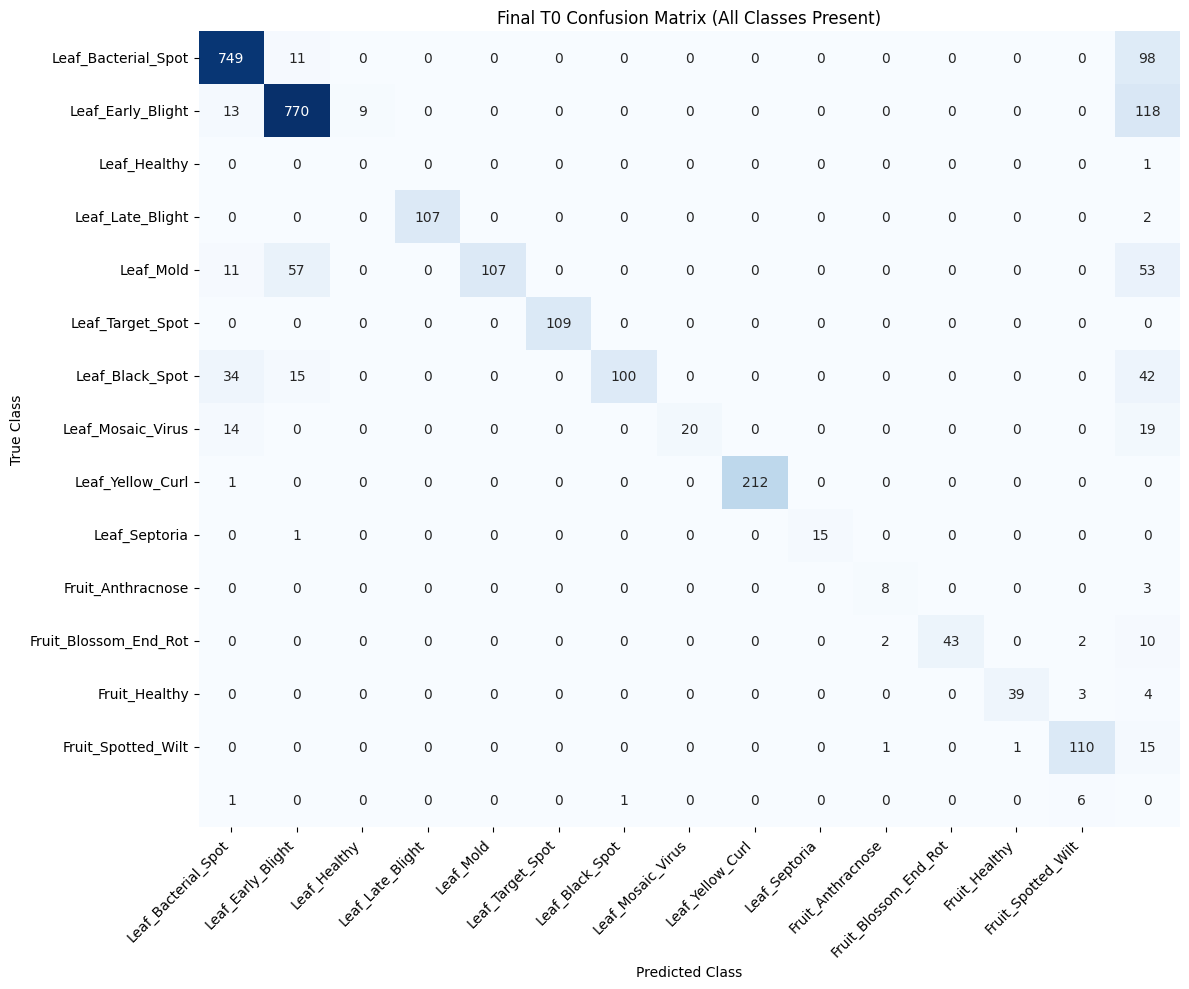


✅ Metric Check:
mAP@50: 0.9099
mAP@50-95: 0.8334


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from ultralytics import YOLO
import os

# 1. Load the Model
# (Ensure this points to your T0 Clean Build model)
model_path = "/content/drive/MyDrive/YOLOv8_Tomato_Project/Unified_Training_Runs/T0_Clean_Build_V1/weights/best.pt"

if os.path.exists(model_path):
    model = YOLO(model_path)

    # 2. Run Validation on the FIXED dataset
    print("Running Validation (This will now see ALL classes)...")
    metrics = model.val(data="final_t0_config.yaml", split='val')

    # 3. Plot the Matrix
    cm_array = metrics.confusion_matrix.matrix
    class_names = list(model.names.values())

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_array, annot=True, fmt='.0f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, cbar=False)
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.title("Final T0 Confusion Matrix (All Classes Present)")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print("\n✅ Metric Check:")
    print(f"mAP@50: {metrics.box.map50:.4f}")
    print(f"mAP@50-95: {metrics.box.map:.4f}")
else:
    print("❌ Error: Model not found. Check your Drive path.")

Running Validation...
Ultralytics 8.3.230 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,008,378 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1250.8±563.4 MB/s, size: 58.6 KB)
val: Scanning /content/Unified_Tomato_Dataset_V1/val/labels.cache... 2549 images, 37 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2549/2549 178.4Kit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 58, len(boxes) = 2572. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 160/160 5.4it/s 29.7s
                   all       2549       2572      0.914      0.867       0.91      0.833
   Leaf_Bacterial_Spot        822        823      0.943      0.881      0.951      0.94

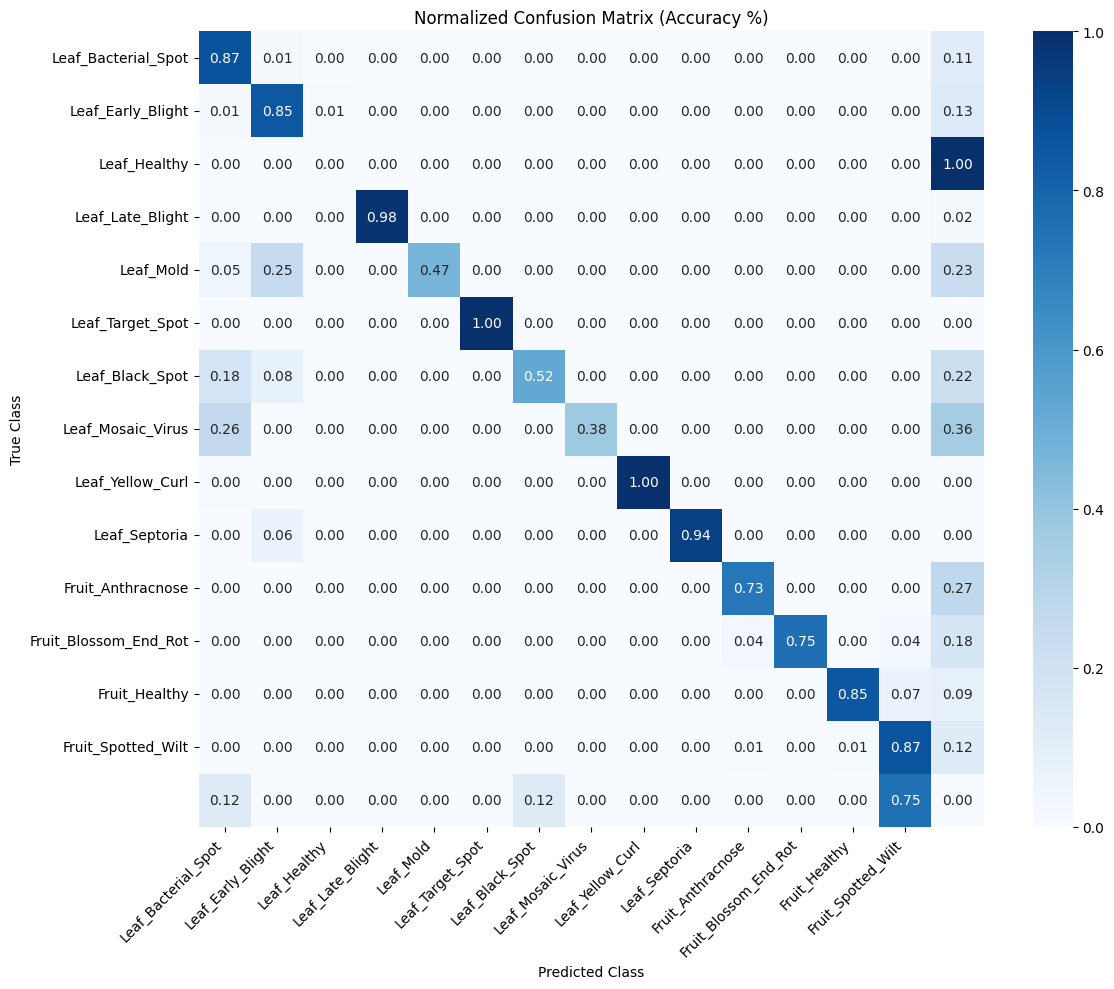

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from ultralytics import YOLO
import numpy as np
import os

# 1. Load Model
model_path = "/content/drive/MyDrive/YOLOv8_Tomato_Project/Unified_Training_Runs/T0_Clean_Build_V1/weights/best.pt"

if os.path.exists(model_path):
    model = YOLO(model_path)

    print("Running Validation...")
    metrics = model.val(data="final_t0_config.yaml", split='val')

    # 2. Get Raw Matrix
    cm_array = metrics.confusion_matrix.matrix

    # 3. NORMALIZE IT (Row-wise)
    # We divide each cell by the sum of its row (True Class Total)
    # This gives us the percentage (0.00 - 1.00)
    row_sums = cm_array.sum(axis=1, keepdims=True)
    # Avoid division by zero just in case
    row_sums[row_sums == 0] = 1
    cm_normalized = cm_array / row_sums

    # 4. Plot
    class_names = list(model.names.values())

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt='.2f',       # Show 2 decimal places (e.g. 0.95)
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=True
    )

    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.title("Normalized Confusion Matrix (Accuracy %)")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("❌ Error: Model not found.")